## 1. Imports

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

plt.rcParams["figure.dpi"] = 110
print("OpenCV:", cv2.__version__)


OpenCV: 4.13.0


## 2. Load Image

Shape: (512, 576, 3)


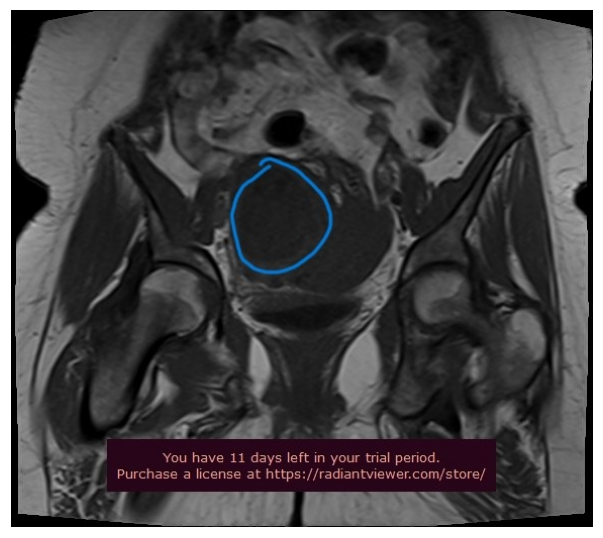

In [4]:
IMAGE_PATH = "/content/coronal T1.jpg"

img_bgr  = cv2.imread(IMAGE_PATH)
img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

print("Shape:", img_bgr.shape)   # (512, 576, 3)

plt.figure(figsize=(6, 5))
plt.imshow(img_rgb)
plt.axis("off")
plt.tight_layout()
plt.show()


## 3. BGR → HSV

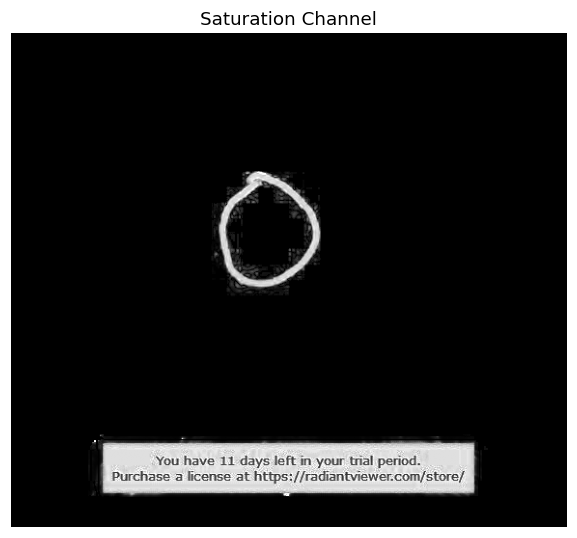

In [8]:
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

# Display only the Saturation channel
plt.figure(figsize=(6, 5))
plt.imshow(img_hsv[:, :, 1], cmap="gray") # Saturation channel is the second (index 1)
plt.title("Saturation Channel", fontsize=12)
plt.axis("off")
plt.tight_layout()
plt.show()

## 4. Threshold — Isolate the Blue Annotation

Blue pixels detected: 3145


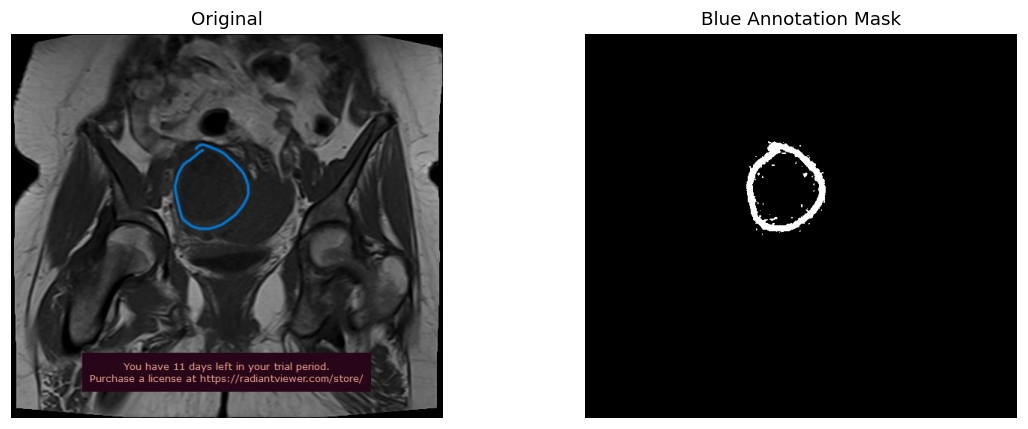

In [10]:
lower = np.array([100, 50, 25],  dtype=np.uint8)
upper = np.array([115, 255, 255], dtype=np.uint8)

blue_mask = cv2.inRange(img_hsv, lower, upper)
print(f"Blue pixels detected: {blue_mask.sum()//255}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(img_rgb);          axes[0].set_title("Original");          axes[0].axis("off")
axes[1].imshow(blue_mask, cmap="gray"); axes[1].set_title("Blue Annotation Mask"); axes[1].axis("off")
plt.tight_layout()
plt.show()

## 5. Morphological Operations — Close the Circle Stroke


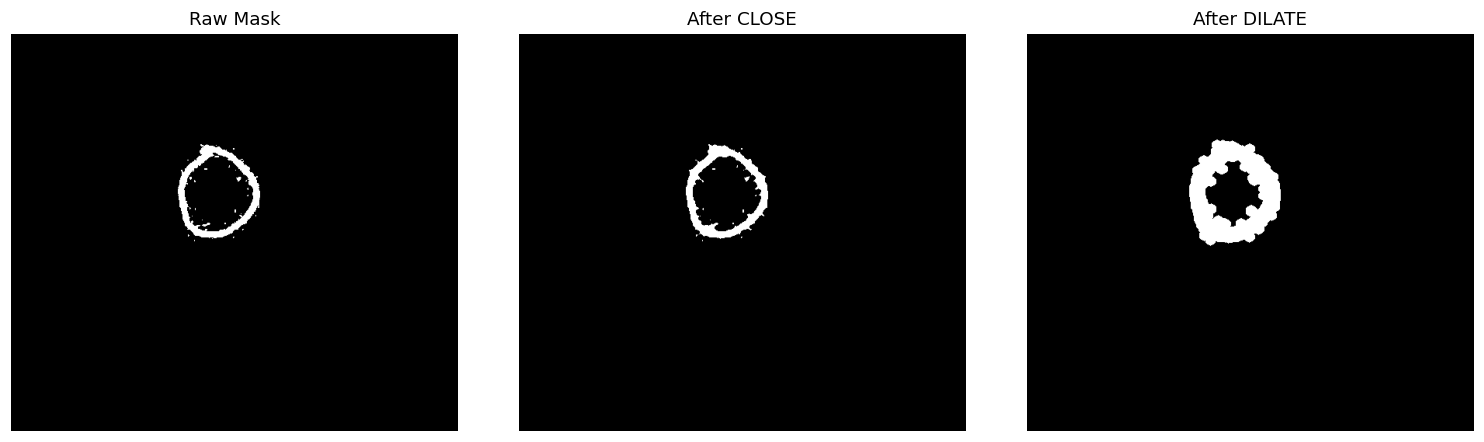

In [11]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))

# Close: fills small gaps in the stroke
closed  = cv2.morphologyEx(blue_mask, cv2.MORPH_CLOSE,  kernel)
# Dilate: thicken the ring slightly to ensure closure
dilated = cv2.dilate(closed, kernel, iterations=2)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, img_show, title in zip(axes,
    [blue_mask, closed, dilated],
    ["Raw Mask", "After CLOSE", "After DILATE"]):
    ax.imshow(img_show, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 6. Fill Interior → Binary ROI Mask

ROI area: 12230 px²  (4.1% of image)


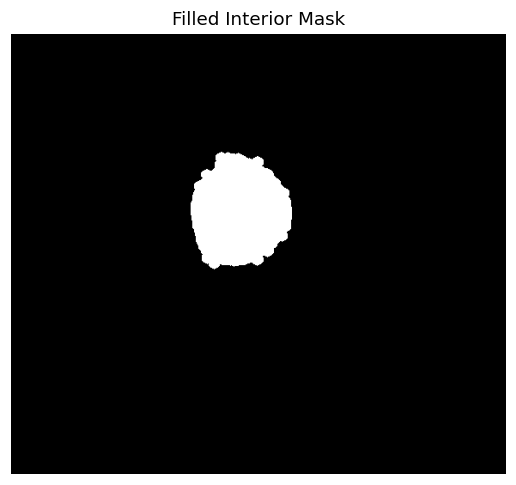

In [13]:
h, w = img_bgr.shape[:2]
filled_mask = np.zeros((h, w), dtype=np.uint8)
cv2.drawContours(filled_mask, [contours[0]], -1, 255, thickness=cv2.FILLED)

# Quick shape analysis
area_px = filled_mask.sum() // 255
print(f"ROI area: {area_px} px²  ({area_px / (h*w)*100:.1f}% of image)")

plt.figure(figsize=(5, 4.5))
plt.imshow(filled_mask, cmap="gray")
plt.title("Filled Interior Mask")
plt.axis("off")
plt.tight_layout()
plt.show()


## 7. Apply Mask → Extract Anatomical Region

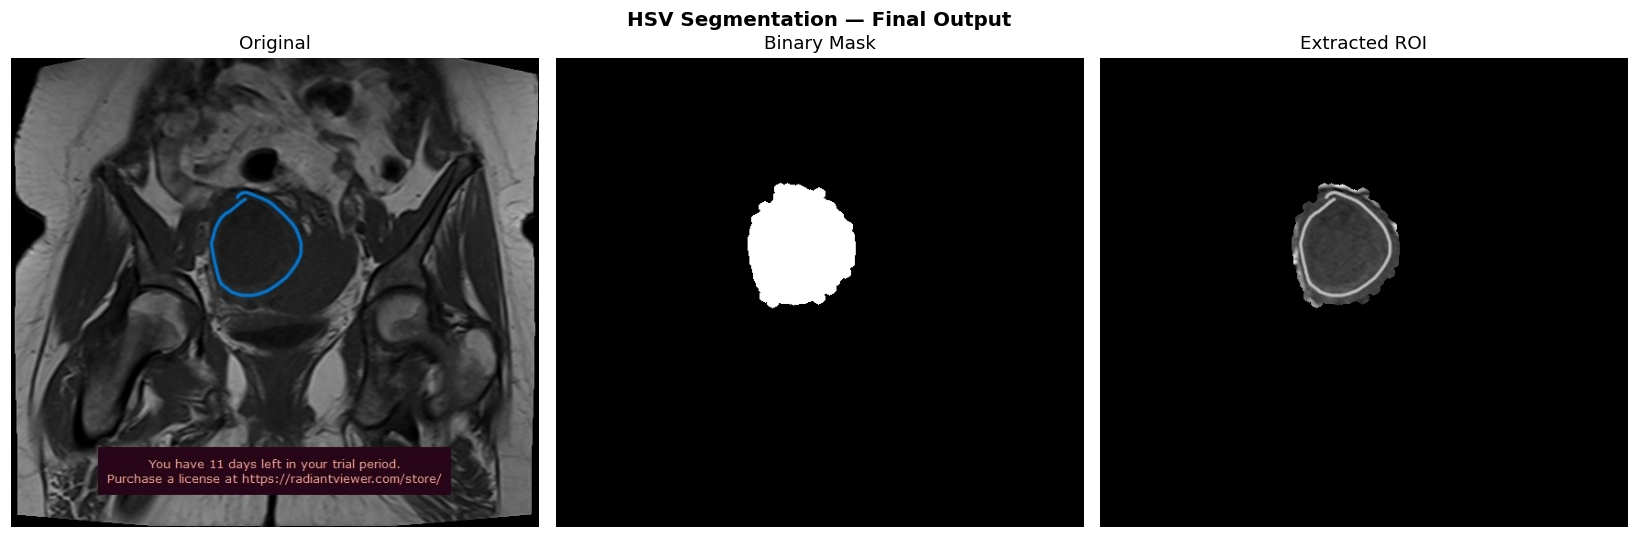

In [14]:
roi_gray  = cv2.bitwise_and(img_gray, img_gray, mask=filled_mask)
roi_color = cv2.bitwise_and(img_rgb,  img_rgb,  mask=filled_mask)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_rgb);            axes[0].set_title("Original");            axes[0].axis("off")
axes[1].imshow(filled_mask, cmap="gray"); axes[1].set_title("Binary Mask"); axes[1].axis("off")
axes[2].imshow(roi_gray, cmap="gray");   axes[2].set_title("Extracted ROI"); axes[2].axis("off")
plt.suptitle("HSV Segmentation — Final Output", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
